In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Training images:", x_train.shape)
print("Test images:", x_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training images: (60000, 28, 28)
Test images: (10000, 28, 28)


In [3]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [4]:
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

print(x_train.shape)

(60000, 784)


In [5]:
model = keras.Sequential([

    layers.Dense(128, activation='relu', input_shape=(784,)),  # Hidden layer

    layers.Dropout(0.2),  # Dropout layer

    layers.Dense(10, activation='softmax')  # Output layer

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [7]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9129 - loss: 0.2993 - val_accuracy: 0.9598 - val_loss: 0.1363
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9581 - loss: 0.1419 - val_accuracy: 0.9700 - val_loss: 0.1005
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9674 - loss: 0.1081 - val_accuracy: 0.9757 - val_loss: 0.0806
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9729 - loss: 0.0880 - val_accuracy: 0.9788 - val_loss: 0.0720
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9769 - loss: 0.0746 - val_accuracy: 0.9783 - val_loss: 0.0774
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9796 - loss: 0.0649 - val_accuracy: 0.9787 - val_loss: 0.0673
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9824 - loss: 0.0564 - val_accuracy: 0.9780 - val_loss: 0.0744
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9823 - loss: 0.0539 - 

In [8]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9810 - loss: 0.0702
Test Accuracy: 0.9810000061988831


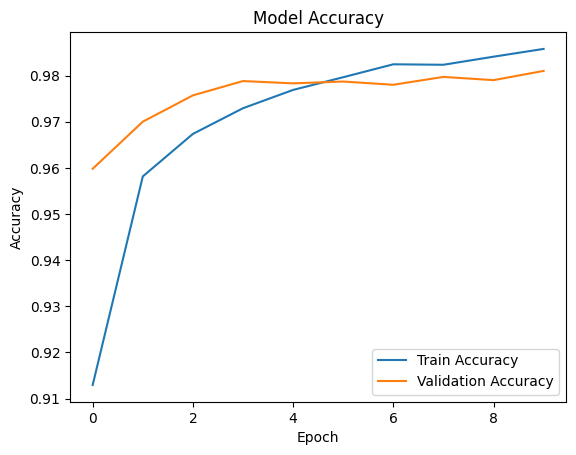

In [9]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

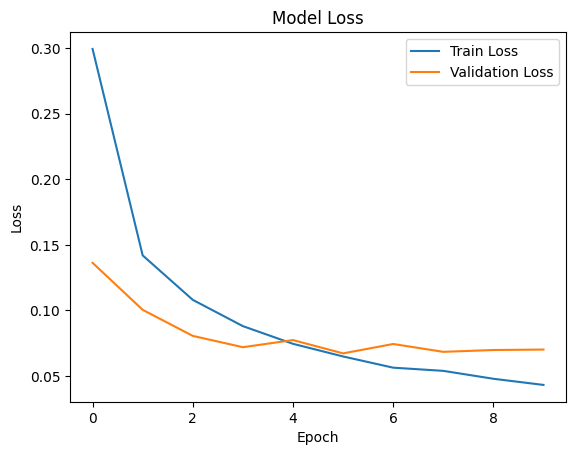

In [10]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [15]:
import numpy as np

index = 1   # choose any test image index

prediction = model.predict(x_test[index:index+1])
predicted_label = np.argmax(prediction)

print("Predicted Digit:", predicted_label)
print("Actual Digit:", y_test[index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Predicted Digit: 2
Actual Digit: 2


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


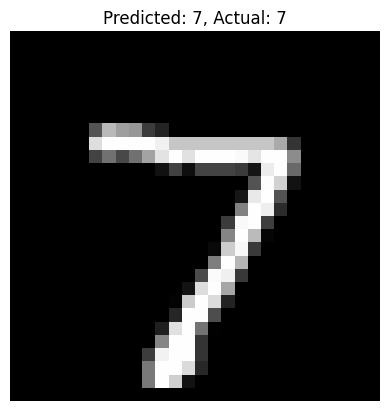

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


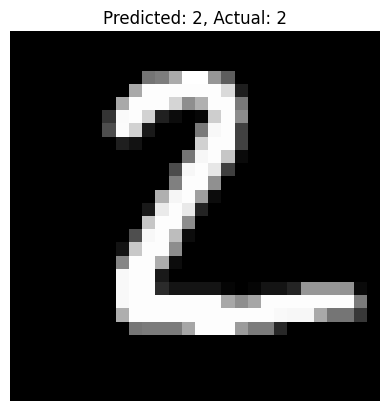

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


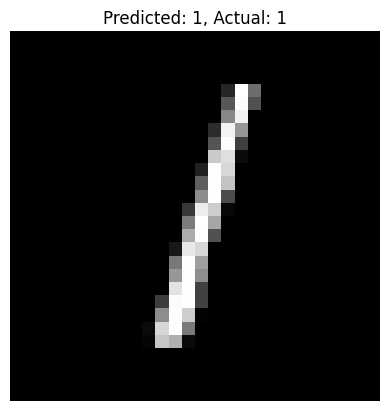

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


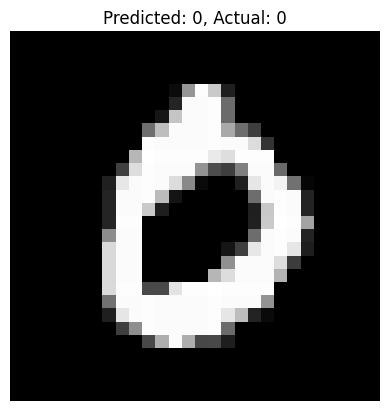

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


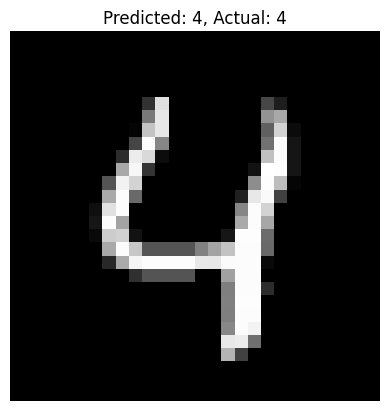

In [20]:
for i in range(5):
    prediction = model.predict(x_test[i:i+1])
    predicted = np.argmax(prediction)

    plt.imshow(x_test[i].reshape(28,28), cmap="gray")
    plt.title(f"Predicted: {predicted}, Actual: {y_test[i]}")
    plt.axis("off")
    plt.show()

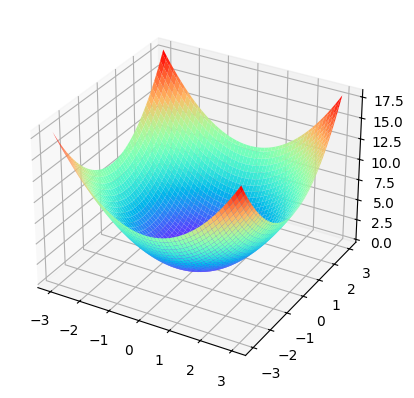

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

w0 = np.linspace(-3,3,100)
w1 = np.linspace(-3,3,100)

W0, W1 = np.meshgrid(w0,w1)

Loss = W0**2 + W1**2

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W0, W1, Loss, cmap='rainbow')

plt.show()